In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from matplotlib import pyplot as plt
import time

import hssm
from hssm.distribution_utils import make_distribution_for_supported_model

from efficient_fpt.addm import simulate_addm

print(f"PyMC version: {pm.__version__}")
print(f"hssm version: {hssm.__version__}")

ANGLE = make_distribution_for_supported_model("angle", loglik_kind="approx_differentiable")
print("HSSM Angle distribution loaded.")

PyMC version: 5.28.4
hssm version: 0.3.0
HSSM Angle distribution loaded.


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
NUM_TRIALS     = 500
FIXED_SIGMA    = 1.0
FIXATION_SHAPE = 6
FIXATION_SCALE = 0.1
SIM_DT         = 1e-4

N_DRAWS  = 500
N_TUNE   = 200
N_CHAINS = 2
SEED     = 42

# ── True parameters ───────────────────────────────────────────────────────────
# b is the aDDM slope (boundary = a - b*t), drawn in [0, 1].
# The equivalent HSSM Angle parameter is theta = arctan(b).
TRUE_PARAMS = {
    'eta':   0.3,
    'kappa': 0.5,
    'sigma': FIXED_SIGMA,
    'a':     2.0,
    'b':     0.3,            # slope; tan(theta_true) = b
    'x0':    0.0,
}
TRUE_PARAMS['theta'] = float(np.arctan(TRUE_PARAMS['b']))

print("True parameters:")
for k, v in TRUE_PARAMS.items():
    print(f"  {k}: {v:.6f}")

True parameters:
  eta: 0.300000
  kappa: 0.500000
  sigma: 1.000000
  a: 2.000000
  b: 0.300000
  x0: 0.000000
  theta: 0.291457


In [22]:
# ── Simulate dataset (Cython aDDM simulator) ─────────────────────────────────
b = TRUE_PARAMS['b']
a = TRUE_PARAMS['a']
max_t = max(10.0, a / b) if b > 0.0 else 10.0

t0 = time.perf_counter()
out = simulate_addm(
    n_trials=NUM_TRIALS,
    eta=TRUE_PARAMS['eta'],
    kappa=TRUE_PARAMS['kappa'],
    sigma=TRUE_PARAMS['sigma'],
    a=a,
    b=b,
    x0=TRUE_PARAMS['x0'],
    gamma_shape=FIXATION_SHAPE,
    gamma_scale=FIXATION_SCALE,
    r_range=(1, 5),
    dt=SIM_DT,
    max_t=max_t,
    random_state=SEED,
)
print(f"Simulation completed in {time.perf_counter() - t0:.2f}s")

rt_data       = out['rt'].astype(np.float64)
choice_data   = out['choice'].astype(np.int32)
d_data        = out['d_data'].astype(np.int32)
r1_data       = out['r1'].astype(np.float64)
r2_data       = out['r2'].astype(np.float64)
flag_data     = out['flag'].astype(np.int32)
sacc_data_padded = out['sacc_data_padded'].astype(np.float64)
mu_data_padded   = out['mu_data_padded'].astype(np.float64)

# Drop non-terminated trials
terminated = rt_data > 0
if not np.all(terminated):
    keep = np.where(terminated)[0]
    rt_data = rt_data[keep]; choice_data = choice_data[keep]
    d_data  = d_data[keep];  r1_data = r1_data[keep]; r2_data = r2_data[keep]
    flag_data = flag_data[keep]; sacc_data_padded = sacc_data_padded[keep]
    mu_data_padded = mu_data_padded[keep]

# Keep only trials with at most 10 fixations
# short = d_data <= 10
# if not np.all(short):
#     keep = np.where(short)[0]
#     rt_data = rt_data[keep]; choice_data = choice_data[keep]
#     d_data  = d_data[keep];  r1_data = r1_data[keep]; r2_data = r2_data[keep]
#     flag_data = flag_data[keep]; sacc_data_padded = sacc_data_padded[keep]
#     mu_data_padded = mu_data_padded[keep]

max_d = int(d_data.max())
# max_d = 5
sacc_data_padded = np.ascontiguousarray(sacc_data_padded[:, :max_d])

print(f"  Trials: {len(rt_data)}, max stages: {max_d}")
print(f"  RT range: [{rt_data.min():.4f}, {rt_data.max():.4f}]")
print(f"  Upper choices: {np.sum(choice_data == 1)} ({100*np.mean(choice_data == 1):.1f}%)")

Simulation completed in 0.36s
  Trials: 500, max stages: 23
  RT range: [0.2880, 4.7562]
  Upper choices: 264 (52.8%)


In [6]:
# ── Simulate dataset (pure-Python aDDModel via simulate_fpt_datum) ────────────
# Mirrors the simulation used in param_recovery_main.py, which avoids the
# heavily zero-padded saccade arrays produced by the Cython simulator.
from efficient_fpt.models import DDModel, piecewise_const_func
from efficient_fpt.utils import get_alternating_mu_array


class aDDModel(DDModel):
    """Single-trial attentional DDM."""
    def __init__(self, mu1, mu2, sacc_array, flag, sigma, a, b, x0):
        super().__init__(x0)
        self.mu1 = mu1
        self.mu2 = mu2
        self.sacc_array = sacc_array
        self.flag = flag
        self.d = len(sacc_array)
        self.mu_array = get_alternating_mu_array(mu1, mu2, self.d, flag)
        self.sigma = sigma
        self.a = a
        self.b = b

    def drift_coeff(self, X, t):
        return piecewise_const_func(t, self.mu_array, self.sacc_array)

    def diffusion_coeff(self, X, t):
        return self.sigma

    @property
    def is_update_vectorizable(self):
        return True

    def upper_bdy(self, t):
        return self.a - self.b * t

    def lower_bdy(self, t):
        return -self.a + self.b * t


def _simulate_trial_py(rng, eta, kappa, sigma, a, b, x0,
                       t_max, shape, scale):
    fixations  = rng.gamma(shape, scale, 100)
    sacc_array = np.insert(np.cumsum(fixations), 0, 0)
    sacc_array = sacc_array[sacc_array < t_max]

    flag = rng.integers(0, 2)
    r1   = rng.integers(1, 6)
    r2   = rng.integers(1, 6)

    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)

    model = aDDModel(mu1, mu2, sacc_array, flag, sigma, a, b, x0)
    rt, choice = model.simulate_fpt_datum(dt=SIM_DT)

    sacc_array = sacc_array[sacc_array < rt]
    d = len(sacc_array)
    mu_array = get_alternating_mu_array(mu1, mu2, d, flag)
    return rt, int(choice), d, r1, r2, flag, mu1, mu2, mu_array, sacc_array


a    = TRUE_PARAMS['a']
b    = TRUE_PARAMS['b']
tmax = a / b if b > 0.0 else 10.0

rng = np.random.default_rng(SEED)
trials = []
t0 = time.perf_counter()
for _ in range(NUM_TRIALS):
    trials.append(_simulate_trial_py(
        rng, TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], TRUE_PARAMS['sigma'],
        a, b, TRUE_PARAMS['x0'], tmax, FIXATION_SHAPE, FIXATION_SCALE,
    ))
print(f"Python simulation completed in {time.perf_counter() - t0:.2f}s")

rt_data     = np.array([t[0] for t in trials], dtype=np.float64)
choice_data = np.array([t[1] for t in trials], dtype=np.int32)
d_data      = np.array([t[2] for t in trials], dtype=np.int32)
r1_data     = np.array([t[3] for t in trials], dtype=np.float64)
r2_data     = np.array([t[4] for t in trials], dtype=np.float64)
flag_data   = np.array([t[5] for t in trials], dtype=np.int32)
mu1_data    = np.array([t[6] for t in trials], dtype=np.float64)
mu2_data    = np.array([t[7] for t in trials], dtype=np.float64)

# Drop trials that did not terminate
terminated = rt_data > 0
if not np.all(terminated):
    keep = np.where(terminated)[0]
    rt_data = rt_data[keep]; choice_data = choice_data[keep]
    d_data = d_data[keep]; r1_data = r1_data[keep]; r2_data = r2_data[keep]
    flag_data = flag_data[keep]
    trials = [trials[i] for i in keep]

max_d = int(d_data.max())
mu_data_padded   = np.zeros((len(trials), max_d), dtype=np.float64)
sacc_data_padded = np.zeros((len(trials), max_d), dtype=np.float64)
for i, t in enumerate(trials):
    di = t[2]
    mu_data_padded[i, :di]   = t[8]
    sacc_data_padded[i, :di] = t[9]

sacc_data_padded = np.ascontiguousarray(sacc_data_padded)

print(f"  Trials: {len(rt_data)}, max stages: {max_d}")
print(f"  RT range: [{rt_data.min():.4f}, {rt_data.max():.4f}]")
print(f"  Upper choices: {np.sum(choice_data == 1)} ({100*np.mean(choice_data == 1):.1f}%)")


Python simulation completed in 168.53s
  Trials: 500, max stages: 9
  RT range: [0.2017, 4.9868]
  Upper choices: 237 (47.4%)


In [7]:
sacc_data_padded[0]

array([0.        , 0.64234295, 1.40708286, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [8]:
# ── Helper functions: padded mu array and time-averaged drift ──────────────────

def get_mu_padded(mu1, mu2, max_d, L, flag):
    """(N, max_d) symbolic alternating drift array."""
    idx    = pt.arange(max_d)[None, :]          # (1, max_d)
    parity = (idx + flag[:, None]) % 2          # (N, max_d)
    mu_full = pt.switch(pt.eq(parity, 0), mu1[:, None], mu2[:, None])
    return mu_full * (idx < L[:, None])


def get_mu_tada(mu_data, rt, sacc, L, max_d):
    """Time-averaged drift across fixation stages (TADA)."""
    idx  = pt.arange(max_d)[None, :]
    Lm1  = (L - 1)[:, None]

    dt_mid   = sacc[:, 1:] - sacc[:, :-1]
    mask_mid = idx[:, :-1] < Lm1

    dt_last   = rt[:, None] - sacc
    mask_last = pt.eq(idx, Lm1)

    mu_sum = (
        pt.sum(mu_data[:, :-1] * dt_mid * mask_mid, axis=1) +
        pt.sum(mu_data * dt_last * mask_last, axis=1)
    )
    return mu_sum / rt

In [9]:
# ── Build HSSM Angle model ─────────────────────────────────────────────────────
# Prior on slope: b_raw ~ Beta(2,2) so b in [0,1].
# theta = arctan(b_raw), which maps [0,1] -> [0, pi/4] ≈ [0, 0.785].
# This keeps theta well within HSSM's valid range [-0.1, 1.3] and makes
# the implied prior on b identical to the aDDM Beta(2,2) prior.

dataset = pd.DataFrame({'rt': rt_data, 'response': choice_data})

with pm.Model() as angle_model:
    _rt   = pm.Data("rt",   rt_data.astype("float64"))
    _sacc = pm.Data("sacc", sacc_data_padded.astype("float64"))
    _L    = pm.Data("L",    d_data.astype("int32"))
    _flag = pm.Data("flag", flag_data.astype("int32"))
    _r1   = pm.Data("r1",   r1_data.astype("float64"))
    _r2   = pm.Data("r2",   r2_data.astype("float64"))

    eta   = pm.Normal("eta",   mu=0.0, sigma=1.0)
    kappa = pm.Gamma("kappa",  alpha=2.0, beta=4.0)
    a     = pm.Gamma("a",      alpha=4.0, beta=2.0)
    z     = pm.Uniform("z",    lower=0.01, upper=0.99)

    b_raw = pm.Beta("b_raw", alpha=2.0, beta=2.0)
    b     = pm.Deterministic("b",     b_raw)
    theta = pm.Deterministic("theta", pt.arctan(b_raw))

    mu1      = pm.Deterministic("mu1", kappa * (_r1 - eta * _r2))
    mu2      = pm.Deterministic("mu2", kappa * (eta * _r1 - _r2))
    mu_pad   = get_mu_padded(mu1, mu2, max_d, _L, _flag)
    mu_tada  = pm.Deterministic("mu_glam", get_mu_tada(mu_pad, _rt, _sacc, _L, max_d))

    ANGLE("angle", v=mu_tada, a=a, z=z, t=0.0, theta=theta,
          observed=dataset.values)

print("Model built successfully.")
print(angle_model)

Model built successfully.


In [17]:
# ── Run inference ──────────────────────────────────────────────────────────────
with angle_model:
    trace = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        random_seed=SEED,
        target_accept=0.9,
        return_inferencedata=True,
        progressbar=True,
        cores=N_CHAINS,
    )

var_names = ["kappa", "eta", "a", "z", "b", "theta"]
summary = az.summary(trace, var_names=var_names)
print(summary)

print("\nTrue vs recovered (posterior mean):")
mapping = {'eta': 'eta', 'kappa': 'kappa', 'a': 'a', 'b': 'b', 'theta': 'theta'}
for k, col in mapping.items():
    print(f"  {k:6s}  true={TRUE_PARAMS[k]:.4f}  recovered={summary.loc[col, 'mean']:.4f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta, kappa, a, z, b_raw]


Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
kappa  0.512  0.351   0.015    1.152      0.009    0.015    1220.0     549.0   
eta    0.052  1.097  -2.174    1.887      0.034    0.038    1080.0     364.0   
a      2.006  0.906   0.539    3.683      0.027    0.033    1087.0     674.0   
z      0.516  0.281   0.089    0.990      0.009    0.006     962.0     580.0   
b      0.486  0.227   0.108    0.898      0.006    0.005    1508.0     682.0   
theta  0.437  0.182   0.115    0.736      0.005    0.004    1508.0     682.0   

       r_hat  
kappa    1.0  
eta      1.0  
a        1.0  
z        1.0  
b        1.0  
theta    1.0  

True vs recovered (posterior mean):
  eta     true=0.3000  recovered=0.0520
  kappa   true=0.5000  recovered=0.5120
  a       true=2.0000  recovered=2.0060
  b       true=0.3000  recovered=0.4860
  theta   true=0.2915  recovered=0.4370


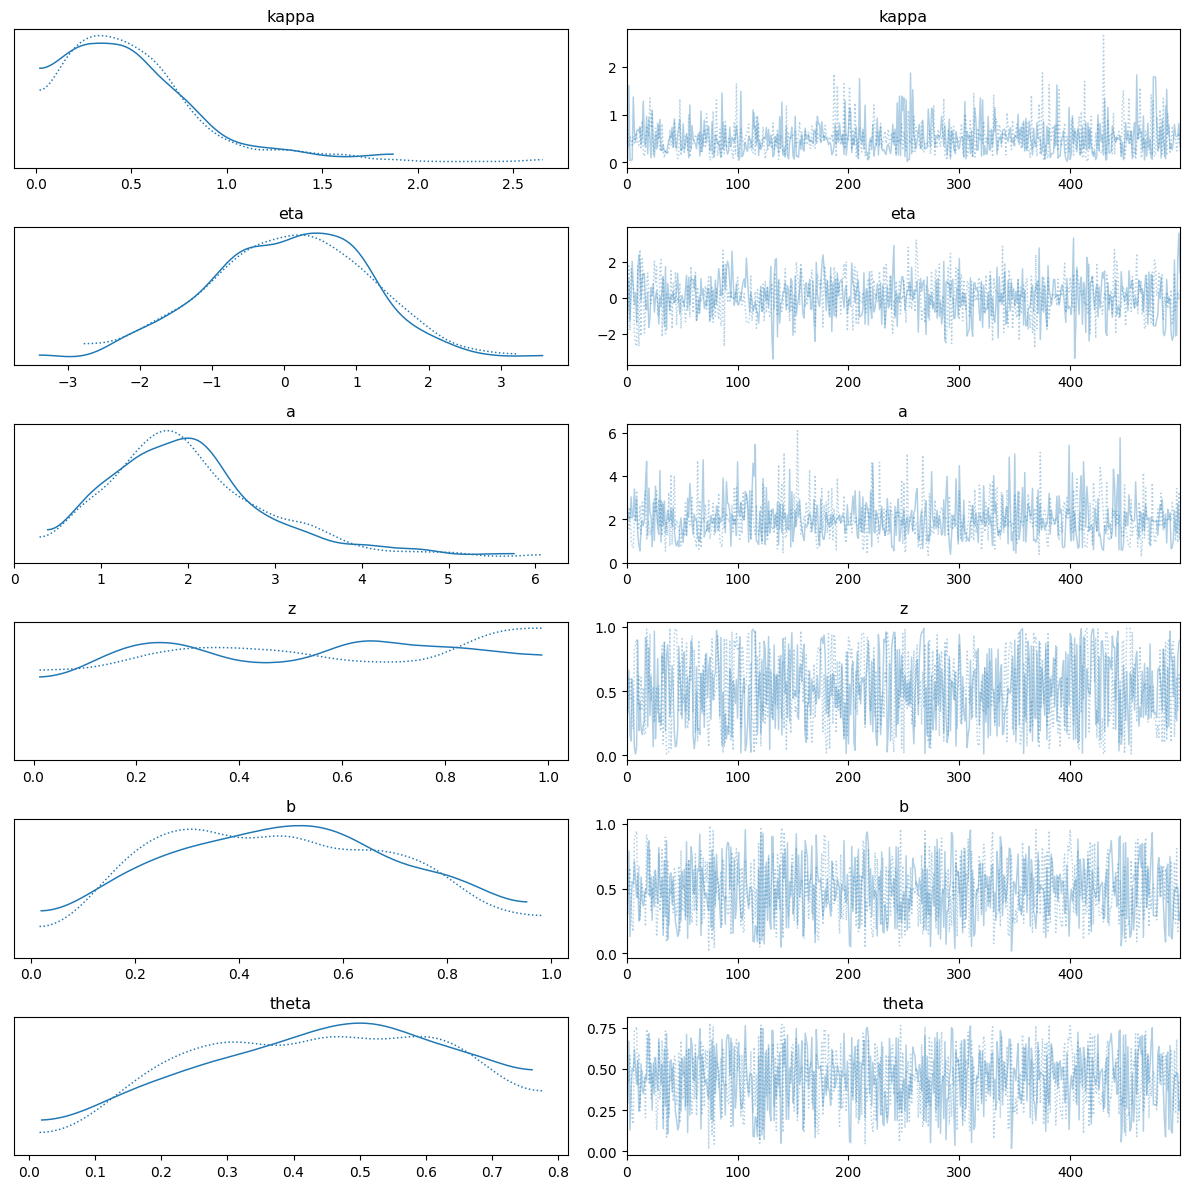

In [18]:
# ── Trace plots ────────────────────────────────────────────────────────────────
az.plot_trace(trace, var_names=["kappa", "eta", "a", "z", "b", "theta"])
plt.tight_layout()
plt.show()

In [10]:
# ── aDDM JAX inference: imports + data setup ──────────────────────────────────
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

TRUNC_NUM = 6  # series truncation for the JAX FPTD

jax_rt     = jnp.array(rt_data)
jax_choice = jnp.array(choice_data)
jax_d      = jnp.array(d_data)
jax_r1     = jnp.array(r1_data)
jax_r2     = jnp.array(r2_data)
jax_flag   = jnp.array(flag_data)
jax_sacc   = jnp.array(sacc_data_padded)

# Pre-compute saccade-padded arrays that are safe for autodiff (avoid NaN grads)
jax_sacc_safe = vmap(lambda s, d: pad_sacc_array_safely(s, d, max_d))(jax_sacc, jax_d)
jax_sacc_safe.block_until_ready()
print(f"  Trials: {jax_rt.shape[0]}, max_d: {max_d}")

JAX version: 0.9.2
JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]
  Trials: 500, max_d: 9


In [12]:
# ── JAX log-likelihood functions ───────────────────────────────────────────────

def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    """Build alternating drift array based on which item is fixated first."""
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    indices = jnp.arange(max_d)
    return jnp.where((indices % 2) == flag, mu1, mu2)


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    """Per-trial aDDM log-likelihood."""
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num, safe_sacc=sacc_safe,
    )
    return jnp.log(jnp.maximum(fptd, 1e-30))


def jax_loglik_batch(eta, kappa, a, b, x0):
    """Total log-likelihood across all trials. JIT-compiled and differentiable."""
    loglik_fn = vmap(
        lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
            rt, choice, d, r1, r2, flag, sacc_safe,
            eta, kappa, a, b, x0, FIXED_SIGMA, max_d, TRUNC_NUM,
        )
    )
    logliks = loglik_fn(jax_rt, jax_choice, jax_d, jax_r1, jax_r2, jax_flag, jax_sacc_safe)
    return jnp.sum(logliks)


jax_loglik_jit = jit(jax_loglik_batch)
jax_grad_loglik = jit(grad(jax_loglik_batch, argnums=(0, 1, 2, 3, 4)))

# Warm up JIT at the true values
print("Warming up JAX JIT...")
_ = jax_loglik_jit(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
                   TRUE_PARAMS['a'],   TRUE_PARAMS['b'],     TRUE_PARAMS['x0'])
_ = jax_grad_loglik(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
                    TRUE_PARAMS['a'],   TRUE_PARAMS['b'],     TRUE_PARAMS['x0'])
print(f"  log-lik at true params: "
      f"{float(jax_loglik_jit(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])):.4f}")

Warming up JAX JIT...
  log-lik at true params: -692.1043


In [13]:
# ── PyTensor Ops wrapping the JAX likelihood (with gradients) ─────────────────
from pytensor.graph.op import Op
from pytensor.link.jax.dispatch import jax_funcify


class LogLikeJAX(Op):
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn   = grad_fn

    def perform(self, node, inputs, outputs):
        (theta_vec,) = inputs
        eta, kappa, a, b, x0 = theta_vec
        loglik = float(self.loglik_fn(eta, kappa, a, b, x0))
        outputs[0][0] = np.array(loglik, dtype="float64")

    def grad(self, inputs, output_grads):
        (theta_vec,) = inputs
        (g_out,)     = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta_vec)
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta_vec,) = inputs
        eta, kappa, a, b, x0 = theta_vec
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


@jax_funcify.register(LogLikeJAX)
def _jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta_vec):
        eta, kappa, a, b, x0 = theta_vec[0], theta_vec[1], theta_vec[2], theta_vec[3], theta_vec[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def _jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta_vec):
        eta, kappa, a, b, x0 = theta_vec[0], theta_vec[1], theta_vec[2], theta_vec[3], theta_vec[4]
        grads = grad_fn(eta, kappa, a, b, x0)
        return jnp.stack(grads)
    return grad_jax


jax_loglike_op = LogLikeJAX(jax_loglik_jit, jax_grad_loglik)
print("Custom JAX Ops registered.")

Custom JAX Ops registered.


In [14]:
# ── Build aDDM PyMC model (recovers eta, kappa, a, b, x0) ─────────────────────
with pm.Model() as addm_model:
    # eta_ad   = pm.Normal("eta",   mu=0.0, sigma=1.0)
    eta_ad = pm.Beta("eta", alpha=2.0, beta=2.0)  # reparameterize to [0,1] for better sampling
    kappa_ad = pm.Gamma("kappa",  alpha=2.0, beta=4.0)
    a_ad     = pm.Gamma("a",      alpha=4.0, beta=2.0)
    b_ad     = pm.Beta("b",       alpha=2.0, beta=2.0)
    x0_raw   = pm.Beta("x0_raw",  alpha=2.0, beta=2.0)
    x0_ad    = pm.Deterministic("x0", -a_ad + 2.0 * a_ad * x0_raw)
    # Equivalent angle for direct comparison with the HSSM Angle posterior
    # theta_eq = pm.Deterministic("theta", pt.arctan(b_ad))

    theta_vec = pt.stack([eta_ad, kappa_ad, a_ad, b_ad, x0_ad])
    pm.Potential("loglik", jax_loglike_op(theta_vec))

print("aDDM model built.")
print(addm_model)

aDDM model built.


In [15]:
# ── Run aDDM inference (numpyro NUTS via JAX) ──────────────────────────────────
with addm_model:
    addm_trace = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=SEED,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
    )

addm_var_names = ["kappa", "eta", "a", "b", "x0_raw", "x0"]
addm_summary = az.summary(addm_trace, var_names=addm_var_names)
print(addm_summary)

print("\nTrue vs recovered (aDDM, posterior mean):")
for k in ['eta', 'kappa', 'a', 'b', 'theta', 'x0']:
    if k in addm_summary.index:
        print(f"  {k:6s}  true={TRUE_PARAMS[k]:.4f}  recovered={addm_summary.loc[k, 'mean']:.4f}")

Running chain 0: 100%|██████████| 700/700 [03:33<00:00,  3.27it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
kappa   0.487  0.024   0.442    0.528      0.001    0.001     403.0     773.0   
eta     0.324  0.040   0.244    0.396      0.002    0.001     568.0     457.0   
a       1.908  0.050   1.820    2.005      0.003    0.002     342.0     587.0   
b       0.278  0.022   0.233    0.317      0.001    0.001     348.0     472.0   
x0_raw  0.498  0.010   0.479    0.516      0.000    0.000     889.0     626.0   
x0     -0.008  0.038  -0.078    0.065      0.001    0.001     884.0     643.0   

        r_hat  
kappa    1.00  
eta      1.00  
a        1.00  
b        1.00  
x0_raw   1.01  
x0       1.01  

True vs recovered (aDDM, posterior mean):
  eta     true=0.3000  recovered=0.3240
  kappa   true=0.5000  recovered=0.4870
  a       true=2.0000  recovered=1.9080
  b       true=0.3000  recovered=0.2780
  x0      true=0.0000  recovered=-0.0080


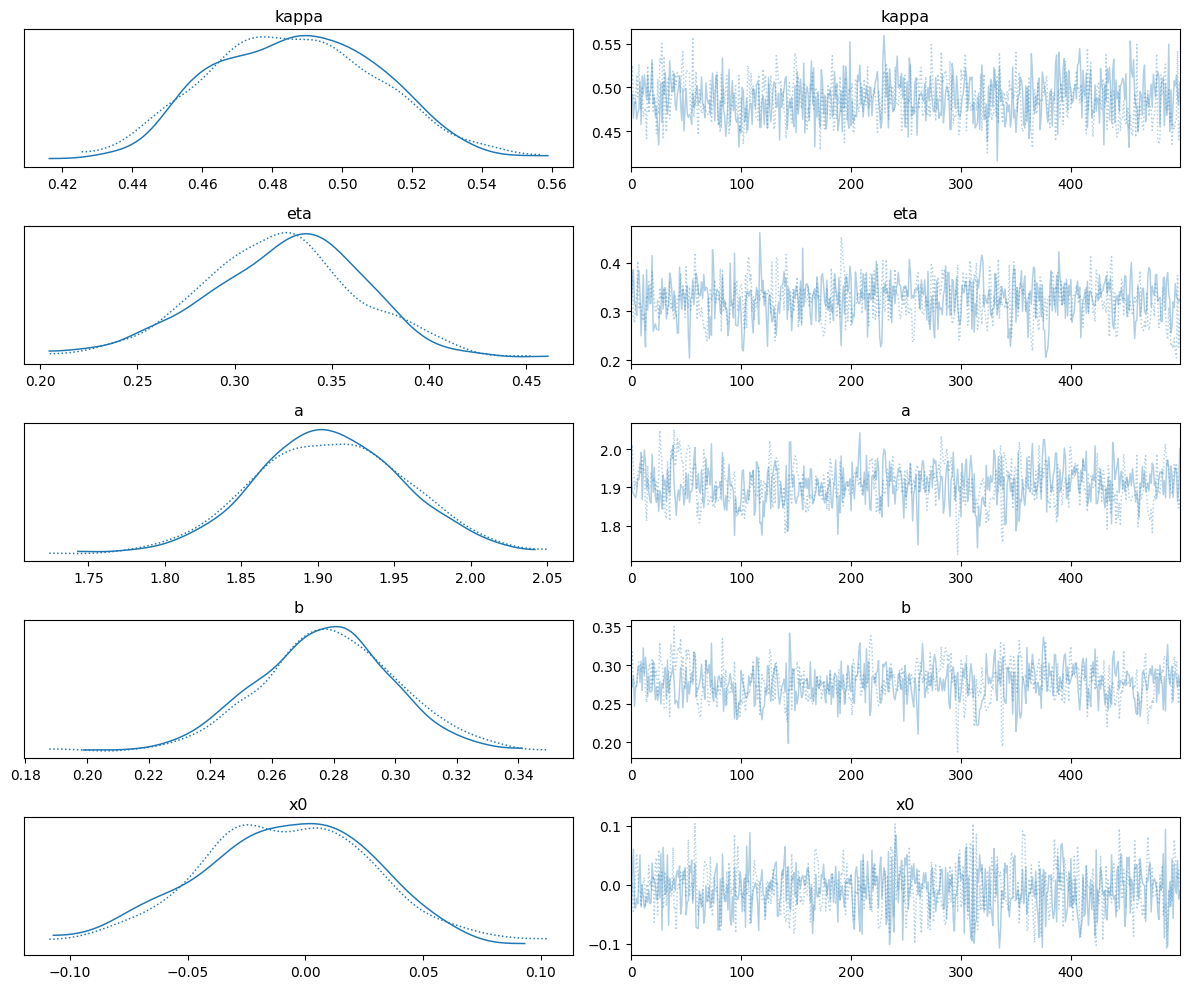


Slope (b) recovery comparison:
  True b:           0.3000
  Angle recovered:  0.4860  (theta=0.4370)


KeyError: 'theta'

In [20]:
# ── Trace plots + Angle vs aDDM slope comparison ──────────────────────────────
az.plot_trace(addm_trace, var_names=["kappa", "eta", "a", "b", "x0"])
plt.tight_layout()
plt.show()

print("\nSlope (b) recovery comparison:")
print(f"  True b:           {TRUE_PARAMS['b']:.4f}")
print(f"  Angle recovered:  {summary.loc['b', 'mean']:.4f}  "
      f"(theta={summary.loc['theta', 'mean']:.4f})")
print(f"  aDDM  recovered:  {addm_summary.loc['b', 'mean']:.4f}  "
      f"(theta={addm_summary.loc['theta', 'mean']:.4f})")